# Model 5: Transformer Models

Dataset: Zindi "To Vaccinate or Not to Vaccinate" (tweets labelled Negative, Neutral or Positive towards vaccination).

This notebook covers the Transformer part of our group project. The other notebooks cover Naive Bayes and SVM (baselines), and the 1D-CNN and LSTM. Here every token can attend to every other token in the tweet through self-attention.

Questions for this part:
1. Does a Transformer trained from scratch do better than the baselines on about 7k tweets?
2. How much does pre-training help, and does pre-training on tweets help more than general English?
3. Do class weights (for the small Negative class) or agreement weights (for noisy labels) help?

Experiments:

| ID | Model | Change |
|---|---|---|
| T1 | Transformer encoder from scratch | no pre-training |
| T2 | DistilBERT | general English pre-training (Sanh et al., 2019) |
| T3 | BERTweet | pre-trained on English tweets (Nguyen et al., 2020) |
| T4 | best of T2/T3 | + class-weighted loss |
| T5 | T4 | + agreement-weighted loss |
| T6 | best so far | learning rate sweep |
| T7 | final setup | 3 random seeds |

All choices are made on the validation set. The test set (same 1,500 tweets as the other notebooks) is only used for reporting.

Runs on Google Colab with a T4 GPU (about 30 minutes).

## 0. Setup

In [1]:
# install missing packages on Colab (emoji is used by the BERTweet tokenizer)
import sys, subprocess
if 'google.colab' in sys.modules:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'transformers', 'emoji==0.6.0'], check=False)

In [2]:
import os, re, html, json, math, time, random, copy, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from transformers.utils import logging as hf_logging
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, matthews_corrcoef)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()
sns.set_theme(style='whitegrid', context='notebook')

# settings
QUICK_RUN = False          # True = 1 epoch per model, for a quick test
SEED = 42
CLASS_NAMES = ['Negative', 'Neutral', 'Positive']   # label_idx 0, 1, 2
OUT_DIR = 'results/transformer'
FIG_DIR = f'{OUT_DIR}/figures'
os.makedirs(FIG_DIR, exist_ok=True)

DEVICE = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available() else 'cpu')
USE_AMP = DEVICE == 'cuda'
print('Device:', DEVICE, '| torch', torch.__version__)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def savefig(name):
    plt.savefig(f'{FIG_DIR}/{name}.png', dpi=150, bbox_inches='tight')

set_seed(SEED)

Device: mps | torch 2.14.1


## 1. Load the shared splits

Same stratified 70/15/15 split as the rest of the group (`random_state=42`), so results can be compared directly.

In [3]:
BASE = 'https://raw.githubusercontent.com/KABASINGAarsene/formative-2-techniques-1/main/Split%20data'
def load_split(name):
    local = f'Split data/{name}_split.csv'
    return pd.read_csv(local if os.path.exists(local) else f'{BASE}/{name}_split.csv')

train_df, val_df, test_df = (load_split(s) for s in ['train', 'val', 'test'])
for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'{name:5s} {len(d):5d} rows | class counts {d.label_idx.value_counts().sort_index().tolist()}')
train_df.head(3)

train  6999 rows | class counts [726, 3436, 2837]
val    1500 rows | class counts [156, 736, 608]
test   1500 rows | class counts [156, 736, 608]


,tweet_id,safe_text,label,agreement,label_idx
0,PKWJSMW9,<user> <user> my question is if vaccines work ...,0.0,0.666667,1
1,BX9DXKD5,Andrew Wakefield looks like a young Doc Martin...,0.0,1.000000,1
2,DMDB3O4D,20 Million people are working to vaccinate kid...,1.0,1.000000,2


## 2. EDA for the Transformer

The group EDA already looked at class balance and word counts. Here we check things that matter for a Transformer:

- length in subword tokens (to pick `max_len`)
- how the tokenizers split hashtags and rare words
- `<user>`, `<url>`, HTML entities and hashtags
- negation and other context words
- annotator agreement

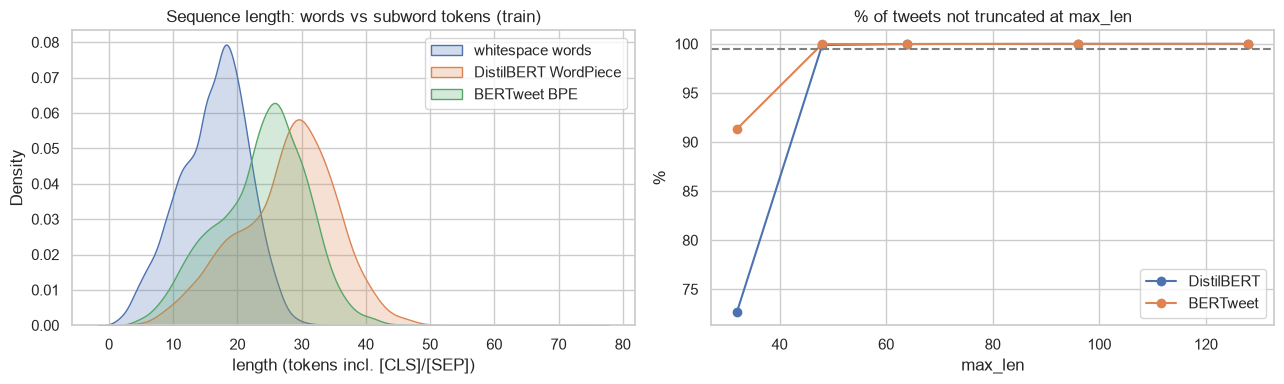

       n_words  n_tok_DistilBERT  n_tok_BERTweet
count   6999.0            6999.0          6999.0
mean      16.3              27.6            23.8
std        5.3               7.7             7.0
min        1.0               4.0             4.0
50%       17.0              29.0            25.0
95%       24.0              39.0            34.0
99%       27.0              44.0            39.0
max       33.0              74.0            74.0

Chosen MAX_LEN = 48 (smallest candidate keeping >=99.5% of tweets untruncated under both tokenizers)


In [4]:
TOK_NAMES = {'DistilBERT': 'distilbert-base-uncased', 'BERTweet': 'vinai/bertweet-base'}
toks = {k: AutoTokenizer.from_pretrained(v, **({'normalization': True} if 'bertweet' in v else {}))
        for k, v in TOK_NAMES.items()}

def normalise(text):
    # fix HTML entities and use BERTweet's tokens for users and links; everything else is kept
    text = html.unescape(str(text))
    text = text.replace('<user>', '@USER').replace('<url>', 'HTTPURL')
    return re.sub(r'\s+', ' ', text).strip()

for d in (train_df, val_df, test_df):
    d['text'] = d['safe_text'].map(normalise)

eda = train_df.copy()
eda['n_words'] = eda.text.str.split().str.len()
for k, t in toks.items():
    eda[f'n_tok_{k}'] = [len(t.encode(s, add_special_tokens=True)) for s in eda.text]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for col, lab in [('n_words', 'whitespace words'), ('n_tok_DistilBERT', 'DistilBERT WordPiece'), ('n_tok_BERTweet', 'BERTweet BPE')]:
    sns.kdeplot(eda[col], ax=ax[0], label=lab, fill=True, alpha=.25)
ax[0].set(title='Sequence length: words vs subword tokens (train)', xlabel='length (tokens incl. [CLS]/[SEP])')
ax[0].legend()

cands = [32, 48, 64, 96, 128]
cov = pd.DataFrame({k: [(eda[f'n_tok_{k}'] <= L).mean() * 100 for L in cands] for k in toks}, index=cands)
cov.plot(marker='o', ax=ax[1])
ax[1].axhline(99.5, ls='--', c='grey'); ax[1].set(title='% of tweets not truncated at max_len', xlabel='max_len', ylabel='%')
plt.tight_layout(); savefig('eda_token_lengths'); plt.show()

print(eda[['n_words', 'n_tok_DistilBERT', 'n_tok_BERTweet']].describe(percentiles=[.5, .95, .99]).round(1))
MAX_LEN = next(L for L in cands if cov.loc[L].min() >= 99.5)
print(f'\nChosen MAX_LEN = {MAX_LEN} (smallest candidate keeping >=99.5% of tweets untruncated under both tokenizers)')

In [5]:
# how many subword pieces each word is split into
def pieces_per_word(tok, words):
    return np.array([len(tok.tokenize(w)) for w in words])

word_freq = Counter(w for s in eda.text for w in s.split())
vocab_words = [w for w, _ in word_freq.most_common()]
hashtags = [w for w in vocab_words if w.startswith('#')]
frag = pd.DataFrame({
    k: {'all word types': pieces_per_word(t, vocab_words).mean(),
        'hashtags': pieces_per_word(t, hashtags).mean(),
        '% word types split into >=3 pieces': (pieces_per_word(t, vocab_words) >= 3).mean() * 100}
    for k, t in toks.items()}).round(2)
print('Mean subword pieces per word type'); display(frag)

ex = ['#vaccineswork', '#whatcausesautism', '#antivax', '#CDCwhistleblower', 'vaccinations', 'unvaccinated', 'measles']
display(pd.DataFrame({k: [' '.join(t.tokenize(w)) for w in ex] for k, t in toks.items()}, index=ex))

# words in the test set that never appear in training
train_vocab = set(w.lower() for s in train_df.text for w in s.split())
test_tokens = [w.lower() for s in test_df.text for w in s.split()]
oov = np.mean([w not in train_vocab for w in test_tokens]) * 100
tweets_with_oov = np.mean([any(w.lower() not in train_vocab for w in s.split()) for s in test_df.text]) * 100
print(f'Word-level OOV on test: {oov:.1f}% of tokens; {tweets_with_oov:.1f}% of test tweets contain >=1 unseen word')
print('Subword tokenizers have no OOV: unseen words are composed from known pieces.')

Mean subword pieces per word type


,DistilBERT,BERTweet
all word types,2.24,1.99
hashtags,4.06,3.18
% word types split into >=3 pieces,30.31,22.76


,DistilBERT,BERTweet
#vaccineswork,# vaccines ##work,#v@@ acc@@ ines@@ work
#whatcausesautism,# what ##ca ##uses ##au ##tism,#what@@ caus@@ es@@ autism
#antivax,# anti ##va ##x,#an@@ tiv@@ ax
#CDCwhistleblower,# cdc ##w ##his ##tle ##bl ##ower,#C@@ DC@@ whist@@ leblower
vaccinations,va ##cci ##nation ##s,vacc@@ inations
unvaccinated,un ##vac ##cina ##ted,un@@ vaccinated
measles,me ##as ##les,measles


Word-level OOV on test: 10.8% of tokens; 72.7% of test tweets contain >=1 unseen word
Subword tokenizers have no OOV: unseen words are composed from known pieces.


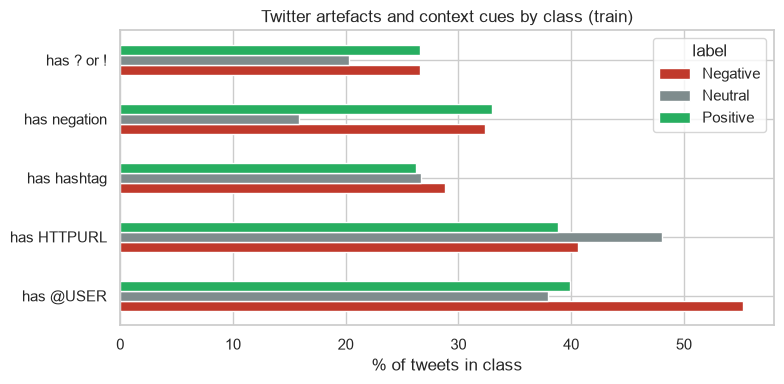

label,Negative,Neutral,Positive
has @USER,55.2,38.0,39.9
has HTTPURL,40.6,48.1,38.9
has hashtag,28.8,26.7,26.3
has negation,32.4,15.9,33.0
has ? or !,26.6,20.3,26.6


In [6]:
# mentions, links, hashtags and negation by class
NEG_WORDS = r"\b(not|no|never|don'?t|doesn'?t|isn'?t|won'?t|can'?t|didn'?t|nothing|nobody)\b"
art = pd.DataFrame({
    'has @USER': train_df.text.str.contains('@USER'),
    'has HTTPURL': train_df.text.str.contains('HTTPURL'),
    'has hashtag': train_df.text.str.contains('#'),
    'has negation': train_df.text.str.lower().str.contains(NEG_WORDS),
    'has ? or !': train_df.text.str.contains(r'[?!]'),
    'label': train_df.label_idx.map(dict(enumerate(CLASS_NAMES)))})
rates = art.groupby('label').mean().T * 100
ax = rates[CLASS_NAMES].plot.barh(figsize=(8, 4), color=['#c0392b', '#7f8c8d', '#27ae60'])
ax.set(xlabel='% of tweets in class', title='Twitter artefacts and context cues by class (train)')
plt.tight_layout(); savefig('eda_artefacts_by_class'); plt.show()
display(rates.round(1))

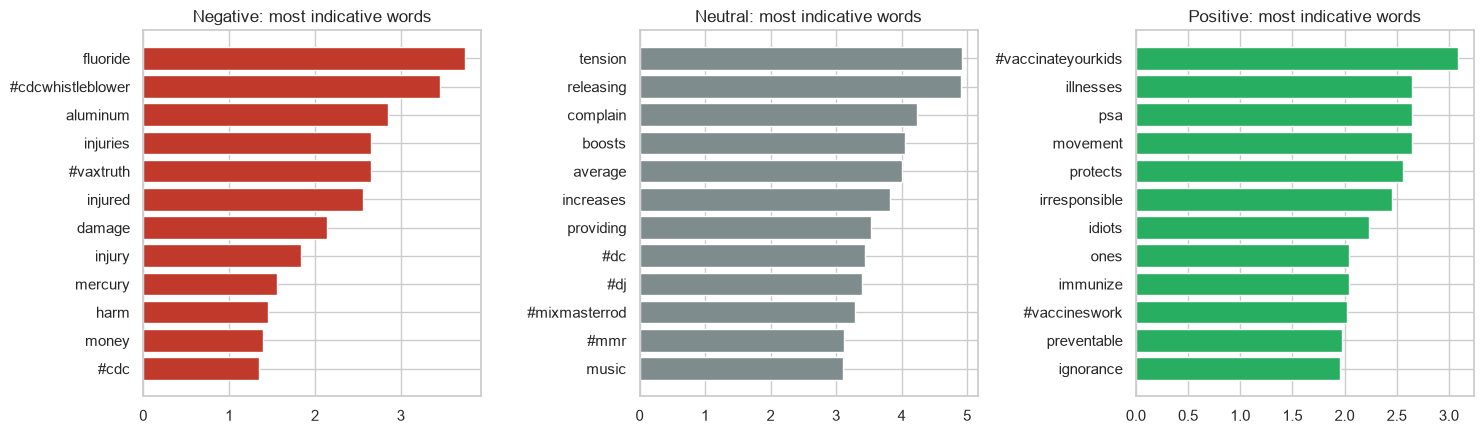

In [7]:
# top words for each class (log-odds ratio, Monroe et al., 2008)
def log_odds(target, k=12, alpha=1.0):
    words = lambda s: re.findall(r"#?\w[\w']*", s.lower())
    c_in = Counter(w for s in train_df.text[train_df.label_idx == target] for w in words(s))
    c_out = Counter(w for s in train_df.text[train_df.label_idx != target] for w in words(s))
    n_in, n_out, V = sum(c_in.values()), sum(c_out.values()), len(set(c_in) | set(c_out))
    lo = {w: math.log((c_in[w] + alpha) / (n_in + alpha * V)) - math.log((c_out[w] + alpha) / (n_out + alpha * V))
          for w in c_in if c_in[w] >= 8}
    return pd.Series(lo).nlargest(k)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for i, ax in enumerate(axes):
    s = log_odds(i)
    ax.barh(s.index[::-1], s.values[::-1], color=['#c0392b', '#7f8c8d', '#27ae60'][i])
    ax.set_title(f'{CLASS_NAMES[i]}: most indicative words')
plt.tight_layout(); savefig('eda_log_odds'); plt.show()

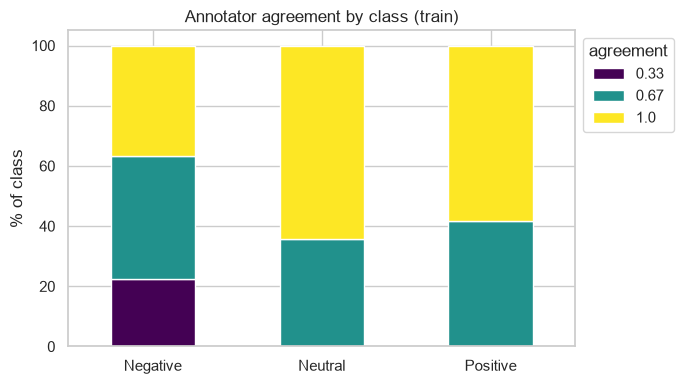

agreement,0.33,0.67,1.00
label,,,
Negative,22.5,40.9,36.6
Neutral,0.0,35.7,64.3
Positive,0.0,41.8,58.2


Low-agreement (<1.0) examples:


,safe_text,label_idx,agreement
4904,“<user> Possible Ebola Vaccines Rely on Cells ...,0,0.333333
4628,#vaccinations All they had when I was young wa...,2,0.666667
5808,<user> why is everyone making such a big deal ...,1,0.666667
1382,Jenny McCarthy is crazy for her stance on vacc...,2,0.666667
5169,6 cases were in infants who depend on those ar...,2,0.666667


In [8]:
# annotator agreement by class
agree = train_df.assign(label=train_df.label_idx.map(dict(enumerate(CLASS_NAMES))),
                        agreement=train_df.agreement.round(2))
tab = pd.crosstab(agree.label, agree.agreement, normalize='index').loc[CLASS_NAMES] * 100
ax = tab.plot.bar(stacked=True, figsize=(7, 4), colormap='viridis')
ax.set(ylabel='% of class', title='Annotator agreement by class (train)', xlabel='')
ax.legend(title='agreement', bbox_to_anchor=(1, 1)); plt.xticks(rotation=0)
plt.tight_layout(); savefig('eda_agreement'); plt.show()
display(tab.round(1))
print('Low-agreement (<1.0) examples:')
display(train_df[train_df.agreement < 1][['safe_text', 'label_idx', 'agreement']].sample(5, random_state=1))

### What we take from the EDA

- Subword sequences are longer than word counts, mostly because WordPiece breaks hashtags into many pieces. `max_len = 48` keeps more than 99.5% of tweets whole, and tweets are short enough that each one fits in a single attention window.
- DistilBERT splits hashtags like `#whatcausesautism` into many small pieces. BERTweet keeps more of them together. About 11% of test words never appear in the training data, which is a problem for word-level models but not for subword tokenizers. This is the reason for testing BERTweet (T3).
- We map `<user>` and `<url>` to `@USER` and `HTTPURL` instead of deleting them, since BERTweet was trained with those tokens and mention/URL rates differ between classes. Stop words are kept here (unlike the TF-IDF baselines) because negation words change the meaning of a tweet.
- Negative is only about 10% of the data. NB found 3% of Negative tweets and SVM 34%. This is why we use macro-F1 and try class weights (T4).
- Only 37% of Negative tweets have full annotator agreement, compared to 64% for Neutral. So the smallest class is also the noisiest. This is why we try agreement weights (T5).

## 3. Evaluation metrics

- **Macro-F1** (main metric). Each class counts equally, so the small Negative class matters as much as Neutral. It is the usual metric for tweet sentiment (Rosenthal et al., 2017; Barbieri et al., 2020). Accuracy alone can look fine while a model ignores Negative tweets (NB had 0.70 accuracy but 0.03 Negative recall).
- **Negative recall and F1.** Hesitant tweets are the ones a health team would care about most.
- **Macro ROC-AUC and average precision.** These don't depend on a threshold. PR curves are more useful than ROC when classes are imbalanced (Saito & Rehmsmeier, 2015).
- **MCC** as a single summary number that works with unequal class sizes (Chicco & Jurman, 2020).
- **RMSE** of the expected score (p(Neg)·-1 + p(Pos)·1), since this was the Zindi leaderboard metric.

One weakness: macro-F1 treats Negative→Positive mistakes the same as Negative→Neutral, even though the first is worse. The confusion matrices and RMSE help with that.

In [9]:
def compute_metrics(y, probs):
    preds = probs.argmax(1)
    p, r, f, _ = precision_recall_fscore_support(y, preds, labels=[0, 1, 2], zero_division=0)
    score = probs @ np.array([-1., 0., 1.])
    return {
        'accuracy': accuracy_score(y, preds),
        'macro_precision': p.mean(), 'macro_recall': r.mean(), 'macro_f1': f.mean(),
        'neg_recall': r[0], 'neg_f1': f[0], 'neu_f1': f[1], 'pos_f1': f[2],
        'mcc': matthews_corrcoef(y, preds),
        'roc_auc_macro': roc_auc_score(y, probs, multi_class='ovr', average='macro'),
        'rmse_score': float(np.sqrt(np.mean((score - (np.asarray(y) - 1)) ** 2))),
    }

## 4. Models and training

**T1 (from scratch):** token + position embeddings, 2 Transformer encoder layers (d=128, 4 heads), mean pooling, linear layer. It uses the DistilBERT tokenizer so the only difference from T2 is pre-training. It is kept small because a bigger model would overfit 7k tweets.

**T2 to T7 (fine-tuned):** pre-trained encoder with a classification head, trained end to end. Settings follow Devlin et al. (2019) and Sun et al. (2019): AdamW, 10% warm-up then linear decay, weight decay 0.01, gradient clipping 1.0, batch size 32, up to 5 epochs, early stopping on validation macro-F1 (patience 2).

In [10]:
class TweetDS(Dataset):
    def __init__(self, df, tok, max_len, use_agreement=False):
        enc = tok(list(df.text), truncation=True, max_length=max_len, padding='max_length', return_tensors='pt')
        self.ids, self.mask = enc['input_ids'], enc['attention_mask']
        self.y = torch.tensor(df.label_idx.values, dtype=torch.long)
        w = df.agreement.fillna(1.0).values if use_agreement else np.ones(len(df))
        self.w = torch.tensor(w, dtype=torch.float)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.ids[i], self.mask[i], self.y[i], self.w[i]


class ScratchTransformer(nn.Module):
    def __init__(self, vocab_size, max_len, d=128, heads=4, layers=2, ff=256, dropout=0.1, n_cls=3, pad_id=0):
        super().__init__()
        self.tok = nn.Embedding(vocab_size, d, padding_idx=pad_id)
        self.pos = nn.Embedding(max_len, d)
        layer = nn.TransformerEncoderLayer(d, heads, ff, dropout, batch_first=True, norm_first=True)
        self.enc = nn.TransformerEncoder(layer, layers)
        self.norm, self.drop, self.head = nn.LayerNorm(d), nn.Dropout(dropout), nn.Linear(d, n_cls)
    def forward(self, input_ids, attention_mask):
        pos = torch.arange(input_ids.size(1), device=input_ids.device)
        h = self.enc(self.tok(input_ids) + self.pos(pos), src_key_padding_mask=attention_mask == 0)
        m = attention_mask.unsqueeze(-1).float()
        h = self.norm((h * m).sum(1) / m.sum(1).clamp(min=1))
        return self.head(self.drop(h))


def logits_of(model, ids, mask):
    out = model(input_ids=ids, attention_mask=mask)
    return out.logits if hasattr(out, 'logits') else out


@torch.no_grad()
def predict(model, loader):
    model.eval(); P, Y, L = [], [], []
    for ids, mask, y, _ in loader:
        ids, mask = ids.to(DEVICE), mask.to(DEVICE)
        with torch.autocast('cuda', enabled=USE_AMP):
            lg = logits_of(model, ids, mask).float()
        L.append(F.cross_entropy(lg, y.to(DEVICE), reduction='sum').item())
        P.append(lg.softmax(-1).cpu().numpy()); Y.append(y.numpy())
    Y = np.concatenate(Y)
    return np.concatenate(P), Y, sum(L) / len(Y)


def run_experiment(exp_id, model_name, lr=2e-5, epochs=5, class_weighted=False, agreement_weighted=False,
                   batch_size=32, patience=2, seed=SEED, scratch=False, note=''):
    set_seed(seed)
    tok_name = 'distilbert-base-uncased' if scratch else model_name
    tok = AutoTokenizer.from_pretrained(tok_name, **({'normalization': True} if 'bertweet' in tok_name else {}))
    if QUICK_RUN: epochs = 1
    tr = TweetDS(train_df, tok, MAX_LEN, agreement_weighted)
    g = torch.Generator().manual_seed(seed)
    tr_dl = DataLoader(tr, batch_size=batch_size, shuffle=True, generator=g)
    va_dl = DataLoader(TweetDS(val_df, tok, MAX_LEN), batch_size=128)
    te_dl = DataLoader(TweetDS(test_df, tok, MAX_LEN), batch_size=128)

    if scratch:
        model = ScratchTransformer(tok.vocab_size, MAX_LEN, pad_id=tok.pad_token_id)
    else:
        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
    model.to(DEVICE)

    cw = None
    if class_weighted:
        cw = torch.tensor(compute_class_weight('balanced', classes=np.arange(3), y=train_df.label_idx),
                          dtype=torch.float, device=DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    steps = epochs * len(tr_dl)
    sched = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    hist, best, best_state, bad, t0 = [], -1, None, 0, time.time()
    for ep in range(1, epochs + 1):
        model.train(); tot, n = 0.0, 0
        for ids, mask, y, w in tr_dl:
            ids, mask, y, w = ids.to(DEVICE), mask.to(DEVICE), y.to(DEVICE), w.to(DEVICE)
            with torch.autocast('cuda', enabled=USE_AMP):
                lg = logits_of(model, ids, mask).float()
            loss = (F.cross_entropy(lg, y, weight=cw, reduction='none') * w).mean()
            opt.zero_grad(); scaler.scale(loss).backward()
            scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); sched.step()
            tot += loss.item() * len(y); n += len(y)
        vp, vy, vloss = predict(model, va_dl)
        vm = compute_metrics(vy, vp)
        hist.append({'epoch': ep, 'train_loss': tot / n, 'val_loss': vloss, 'val_macro_f1': vm['macro_f1'], 'val_acc': vm['accuracy']})
        print(f'  [{exp_id}] epoch {ep}: train_loss={tot/n:.4f} val_loss={vloss:.4f} val_macroF1={vm["macro_f1"]:.4f}')
        if vm['macro_f1'] > best:
            best, bad = vm['macro_f1'], 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience: print(f'  [{exp_id}] early stop'); break

    model.load_state_dict(best_state)
    vp, vy, _ = predict(model, va_dl)
    tp, ty, _ = predict(model, te_dl)
    row = {'exp': exp_id, 'model': 'Scratch Transformer' if scratch else model_name.split('/')[-1], 'lr': lr,
           'class_weighted': class_weighted, 'agreement_weighted': agreement_weighted, 'seed': seed,
           'epochs_run': len(hist), 'best_epoch': int(np.argmax([h['val_macro_f1'] for h in hist]) + 1),
           'params_M': sum(p.numel() for p in model.parameters()) / 1e6, 'train_min': (time.time() - t0) / 60, 'note': note}
    row.update({f'val_{k}': v for k, v in compute_metrics(vy, vp).items()})
    row.update({f'test_{k}': v for k, v in compute_metrics(ty, tp).items()})
    print(f'  [{exp_id}] best val macro-F1 {row["val_macro_f1"]:.4f} | test macro-F1 {row["test_macro_f1"]:.4f} | {row["train_min"]:.1f} min')
    return {'row': row, 'hist': pd.DataFrame(hist), 'test_probs': tp, 'val_probs': vp, 'model': model, 'tok': tok}


RESULTS = {}
BEST = {'exp': None, 'val': -1, 'model': None}   # keep only the best model in memory
def keep(r):
    model = r.pop('model')
    if r['row']['val_macro_f1'] > BEST['val']:
        BEST.update(exp=r['row']['exp'], val=r['row']['val_macro_f1'], model=model.cpu())
    del model
    RESULTS[r['row']['exp']] = r
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    if DEVICE == 'mps': torch.mps.empty_cache()
    return r

## 5. Experiments
### T1 to T3: from scratch vs general pre-training vs tweet pre-training

In [11]:
keep(run_experiment('T1', 'scratch', lr=5e-4, epochs=15, patience=3, scratch=True, note='no pre-training'))
keep(run_experiment('T2', 'distilbert-base-uncased', lr=3e-5, note='general-domain pre-training'))
keep(run_experiment('T3', 'vinai/bertweet-base', lr=2e-5, note='Twitter-domain pre-training'))
pd.DataFrame([RESULTS[k]['row'] for k in ['T1', 'T2', 'T3']])[['exp', 'model', 'params_M', 'val_macro_f1', 'val_neg_recall', 'val_accuracy']].round(4)

  [T1] epoch 1: train_loss=0.8922 val_loss=0.8150 val_macroF1=0.4277


  [T1] epoch 2: train_loss=0.7428 val_loss=0.7569 val_macroF1=0.4848


  [T1] epoch 3: train_loss=0.6666 val_loss=0.7910 val_macroF1=0.4878


  [T1] epoch 4: train_loss=0.5968 val_loss=0.7307 val_macroF1=0.5911


  [T1] epoch 5: train_loss=0.5373 val_loss=0.7383 val_macroF1=0.5750


...

  [T3] epoch 3: train_loss=0.3855 val_loss=0.5776 val_macroF1=0.7224


  [T3] epoch 4: train_loss=0.2912 val_loss=0.6058 val_macroF1=0.7344


  [T3] epoch 5: train_loss=0.2289 val_loss=0.6390 val_macroF1=0.7405


  [T3] best val macro-F1 0.7405 | test macro-F1 0.7512 | 9.3 min


,exp,model,params_M,val_macro_f1,val_neg_recall,val_accuracy
0,T1,Scratch Transformer,4.1786,0.5911,0.2244,0.7040
1,T2,distilbert-base-uncased,66.9558,0.6798,0.4359,0.7567
2,T3,bertweet-base,134.9023,0.7405,0.5513,0.7993


The scratch model starts overfitting after epoch 4 (validation loss goes up). DistilBERT does better, and BERTweet better again, especially on Negative tweets.

The backbone for the next experiments is picked on validation macro-F1.

In [12]:
BACKBONE = max(['T2', 'T3'], key=lambda k: RESULTS[k]['row']['val_macro_f1'])
BB_NAME = {'T2': 'distilbert-base-uncased', 'T3': 'vinai/bertweet-base'}[BACKBONE]
BB_LR = RESULTS[BACKBONE]['row']['lr']
print(f'Backbone for T4+: {BB_NAME} (from {BACKBONE})')

Backbone for T4+: vinai/bertweet-base (from T3)


### T4 and T5: class weights and agreement weights

In [13]:
keep(run_experiment('T4', BB_NAME, lr=BB_LR, class_weighted=True, note='+ class-weighted CE'))
keep(run_experiment('T5', BB_NAME, lr=BB_LR, class_weighted=True, agreement_weighted=True, note='+ class & agreement weights'))
pd.DataFrame([RESULTS[k]['row'] for k in [BACKBONE, 'T4', 'T5']])[['exp', 'note', 'val_macro_f1', 'val_neg_recall', 'val_neg_f1', 'val_neu_f1', 'val_pos_f1']].round(4)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 72934.76it/s]

  [T4] epoch 1: train_loss=0.9044 val_loss=0.7256 val_macroF1=0.6592


  [T4] epoch 2: train_loss=0.5920 val_loss=0.5920 val_macroF1=0.7170


  [T4] epoch 3: train_loss=0.4456 val_loss=0.5540 val_macroF1=0.7354


...

  [T5] epoch 3: train_loss=0.3069 val_loss=0.5545 val_macroF1=0.7355


  [T5] epoch 4: train_loss=0.2337 val_loss=0.6119 val_macroF1=0.7398


  [T5] epoch 5: train_loss=0.1853 val_loss=0.6301 val_macroF1=0.7402


  [T5] best val macro-F1 0.7402 | test macro-F1 0.7511 | 9.6 min


,exp,note,val_macro_f1,val_neg_recall,val_neg_f1,val_neu_f1,val_pos_f1
0,T3,Twitter-domain pre-training,0.7405,0.5513,0.5753,0.8406,0.8057
1,T4,+ class-weighted CE,0.7354,0.5000,0.5571,0.8376,0.8116
2,T5,+ class & agreement weights,0.7402,0.5833,0.5815,0.8367,0.8025


### T6: learning rate sweep

In [14]:
best_so_far = max([BACKBONE, 'T4', 'T5'], key=lambda k: RESULTS[k]['row']['val_macro_f1'])
CW, AW = RESULTS[best_so_far]['row']['class_weighted'], RESULTS[best_so_far]['row']['agreement_weighted']
print(f'Sweeping LR around {best_so_far}: class_weighted={CW}, agreement_weighted={AW}')
lrs = [l for l in [1e-5, 2e-5, 3e-5, 5e-5] if l != BB_LR]
if QUICK_RUN: lrs = lrs[:1]
for l in lrs:
    keep(run_experiment(f'T6-lr{l:g}', BB_NAME, lr=l, class_weighted=CW, agreement_weighted=AW, note=f'LR sweep {l:g}'))

sweep = [best_so_far] + [f'T6-lr{l:g}' for l in lrs]
sweep_df = pd.DataFrame([RESULTS[k]['row'] for k in sweep]).sort_values('lr')
display(sweep_df[['exp', 'lr', 'best_epoch', 'val_macro_f1', 'val_neg_recall']].round({'val_macro_f1': 4, 'val_neg_recall': 4}).assign(lr=lambda d: d.lr.map('{:g}'.format)))
BEST_LR = float(sweep_df.loc[sweep_df.val_macro_f1.idxmax(), 'lr'])
print('Best LR on validation:', BEST_LR)

Sweeping LR around T3: class_weighted=False, agreement_weighted=False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 49745.81it/s]

  [T6-lr1e-05] epoch 1: train_loss=0.8320 val_loss=0.6613 val_macroF1=0.5200


  [T6-lr1e-05] epoch 2: train_loss=0.5796 val_loss=0.6187 val_macroF1=0.6484


...

  [T6-lr5e-05] epoch 4: train_loss=0.1951 val_loss=0.6983 val_macroF1=0.7310


  [T6-lr5e-05] epoch 5: train_loss=0.1172 val_loss=0.8136 val_macroF1=0.7295


  [T6-lr5e-05] best val macro-F1 0.7310 | test macro-F1 0.7508 | 9.4 min


,exp,lr,best_epoch,val_macro_f1,val_neg_recall
1,T6-lr1e-05,1e-05,4,0.7204,0.4936
0,T3,2e-05,5,0.7405,0.5513
2,T6-lr3e-05,3e-05,2,0.7280,0.4808
3,T6-lr5e-05,5e-05,4,0.7310,0.5513


Best LR on validation: 2e-05


### T7: different seeds

Fine-tuning results can change a lot with the random seed on small datasets (Dodge et al., 2020; Mosbach et al., 2021), so the final setup is trained with 3 seeds.

In [15]:
seeds = [42, 7, 2024] if not QUICK_RUN else [42]
final_runs = []
for s in seeds:
    exp = f'T7-seed{s}'
    # reuse the seed 42 run if it was already trained above
    match = [k for k, r in RESULTS.items() if r['row']['model'] == BB_NAME.split('/')[-1] and r['row']['lr'] == BEST_LR
             and r['row']['class_weighted'] == CW and r['row']['agreement_weighted'] == AW and r['row']['seed'] == s]
    if match:
        final_runs.append(match[0]); continue
    keep(run_experiment(exp, BB_NAME, lr=BEST_LR, class_weighted=CW, agreement_weighted=AW, seed=s, note='final config, seed rerun'))
    final_runs.append(exp)

seed_df = pd.DataFrame([RESULTS[k]['row'] for k in final_runs])
cols = ['test_macro_f1', 'test_accuracy', 'test_neg_recall', 'test_roc_auc_macro', 'test_rmse_score']
print('Final configuration over seeds', [RESULTS[k]['row']['seed'] for k in final_runs])
display(seed_df[['exp', 'seed'] + cols].round(4))
print((seed_df[cols].mean().round(4).astype(str) + ' ± ' + seed_df[cols].std().round(4).astype(str)).to_string())

# final model = seed run with the best validation macro-F1
FINAL = max(final_runs, key=lambda k: RESULTS[k]['row']['val_macro_f1'])
print('\nRepresentative final run:', FINAL)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 70585.84it/s]

  [T7-seed7] epoch 1: train_loss=0.7822 val_loss=0.6618 val_macroF1=0.5506


  [T7-seed7] epoch 2: train_loss=0.5360 val_loss=0.5524 val_macroF1=0.6873


  [T7-seed7] epoch 3: train_loss=0.3955 val_loss=0.5809 val_macroF1=0.7215


...

  [T7-seed2024] epoch 4: train_loss=0.3108 val_loss=0.6087 val_macroF1=0.7196


  [T7-seed2024] epoch 5: train_loss=0.2431 val_loss=0.6330 val_macroF1=0.7227


  [T7-seed2024] best val macro-F1 0.7227 | test macro-F1 0.7247 | 9.4 min
Final configuration over seeds [42, 7, 2024]


,exp,seed,test_macro_f1,test_accuracy,test_neg_recall,test_roc_auc_macro,test_rmse_score
0,T3,42,0.7512,0.7973,0.5769,0.9089,0.5140
1,T7-seed7,7,0.7300,0.7853,0.5513,0.9064,0.5302
2,T7-seed2024,2024,0.7247,0.7840,0.5385,0.9022,0.5313


test_macro_f1          0.7353 ± 0.014
test_accuracy         0.7889 ± 0.0073
test_neg_recall       0.5556 ± 0.0196
test_roc_auc_macro    0.9059 ± 0.0034
test_rmse_score       0.5252 ± 0.0097

Representative final run: T3


On validation, plain BERTweet (T3, 0.7405) beat T5 (0.7402) by 0.0003. That is much smaller than the seed standard deviation, so T3 and T5 are basically tied.

## 6. Results

In [16]:
table = pd.DataFrame([r['row'] for r in RESULTS.values()])
show = ['exp', 'model', 'note', 'lr', 'params_M', 'best_epoch', 'train_min', 'val_macro_f1',
        'test_accuracy', 'test_macro_precision', 'test_macro_recall', 'test_macro_f1', 'test_neg_recall',
        'test_mcc', 'test_roc_auc_macro', 'test_rmse_score']
table.to_csv(f'{OUT_DIR}/transformer_experiments.csv', index=False)
print('Full experiment log (selection on val_macro_f1; test reported for completeness)')
display(table[show].round(4).style.background_gradient(subset=['val_macro_f1', 'test_macro_f1'], cmap='Greens')
        .format(precision=4).format({'lr': '{:g}', 'best_epoch': '{:d}'}))

Full experiment log (selection on val_macro_f1; test reported for completeness)


,exp,model,note,lr,params_M,best_epoch,train_min,val_macro_f1,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_neg_recall,test_mcc,test_roc_auc_macro,test_rmse_score
0,T1,Scratch Transformer,no pre-training,0.0005,4.178600,4,0.295900,0.591100,0.725300,0.667200,0.620900,0.632000,0.307700,0.529900,0.840100,0.583500
1,T2,distilbert-base-uncased,general-domain pre-training,0,66.955800,4,4.618300,0.679800,0.765300,0.699200,0.687200,0.692200,0.461500,0.597400,0.885000,0.545800
2,T3,bertweet-base,Twitter-domain pre-training,0,134.902300,5,9.311600,0.740500,0.797300,0.765800,0.743100,0.751200,0.576900,0.655900,0.908900,0.514000
3,T4,bertweet-base,+ class-weighted CE,0,134.902300,3,17.363900,0.735400,0.799300,0.766700,0.733100,0.744800,0.532100,0.659000,0.912900,0.505500
4,T5,bertweet-base,+ class & agreement weights,0,134.902300,5,9.565700,0.740200,0.789300,0.748200,0.758400,0.751100,0.660300,0.646900,0.911900,0.524600
5,T6-lr1e-05,bertweet-base,LR sweep 1e-05,0,134.902300,4,9.494400,0.720400,0.796700,0.746500,0.734100,0.739100,0.551300,0.652700,0.900500,0.510100
6,T6-lr3e-05,bertweet-base,LR sweep 3e-05,0,134.902300,2,7.628300,0.728000,0.800700,0.759900,0.738500,0.746300,0.551300,0.661100,0.915100,0.490400
7,T6-lr5e-05,bertweet-base,LR sweep 5e-05,0,134.902300,4,9.358200,0.731000,0.790700,0.752700,0.752700,0.750800,0.634600,0.647300,0.901700,0.531700
8,T7-seed7,bertweet-base,"final config, seed rerun",0,134.902300,5,9.507600,0.730500,0.785300,0.736400,0.726200,0.730000,0.551300,0.634100,0.906400,0.530200
9,T7-seed2024,bertweet-base,"final config, seed rerun",0,134.902300,5,9.404200,0.722700,0.784000,0.730100,0.721900,0.724700,0.538500,0.632400,0.902200,0.531300


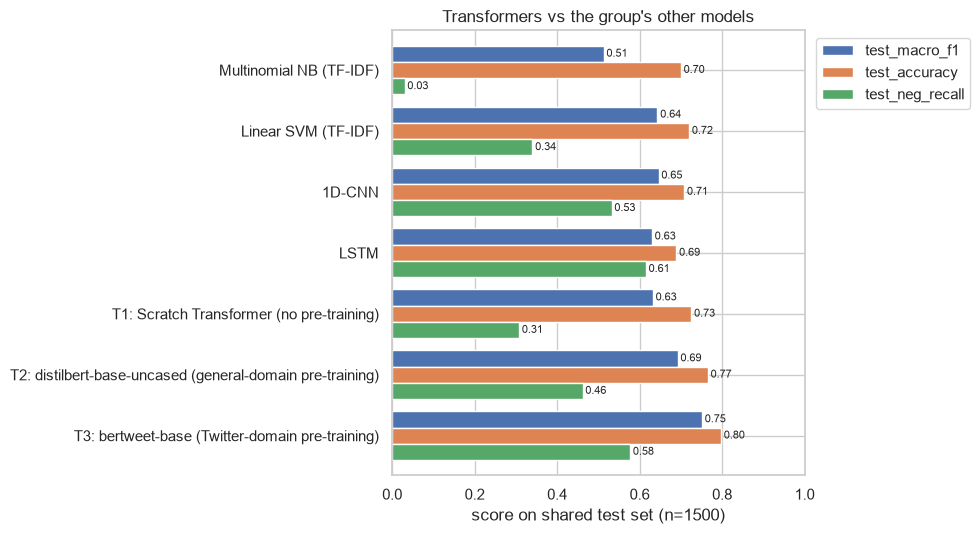

In [17]:
# test results of the other models, taken from their notebooks
baselines = pd.DataFrame([
    {'model': 'Multinomial NB (TF-IDF)', 'test_accuracy': 0.70, 'test_macro_f1': 0.5128, 'test_neg_recall': 0.03},
    {'model': 'Linear SVM (TF-IDF)',     'test_accuracy': 0.72, 'test_macro_f1': 0.6432, 'test_neg_recall': 0.34},
    {'model': '1D-CNN',                  'test_accuracy': 0.708, 'test_macro_f1': 0.6459, 'test_neg_recall': 0.532},
    {'model': 'LSTM',                    'test_accuracy': 0.689, 'test_macro_f1': 0.6298, 'test_neg_recall': 0.615}])
ours = table[table.exp.isin(['T1', 'T2', 'T3', FINAL])].copy()
ours['model'] = ours.exp + ': ' + ours.model + ours.note.map(lambda n: f' ({n})')
comp = pd.concat([baselines, ours[['model', 'test_accuracy', 'test_macro_f1', 'test_neg_recall']]], ignore_index=True)

ax = comp.set_index('model')[['test_macro_f1', 'test_accuracy', 'test_neg_recall']].plot.barh(figsize=(10, 5.5), width=.8)
ax.set(xlabel='score on shared test set (n=1500)', ylabel='', title='Transformers vs the group\'s other models', xlim=(0, 1))
for c in ax.containers: ax.bar_label(c, fmt='%.2f', fontsize=8, padding=2)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1)); ax.invert_yaxis(); plt.tight_layout(); savefig('comparison_vs_baselines'); plt.show()

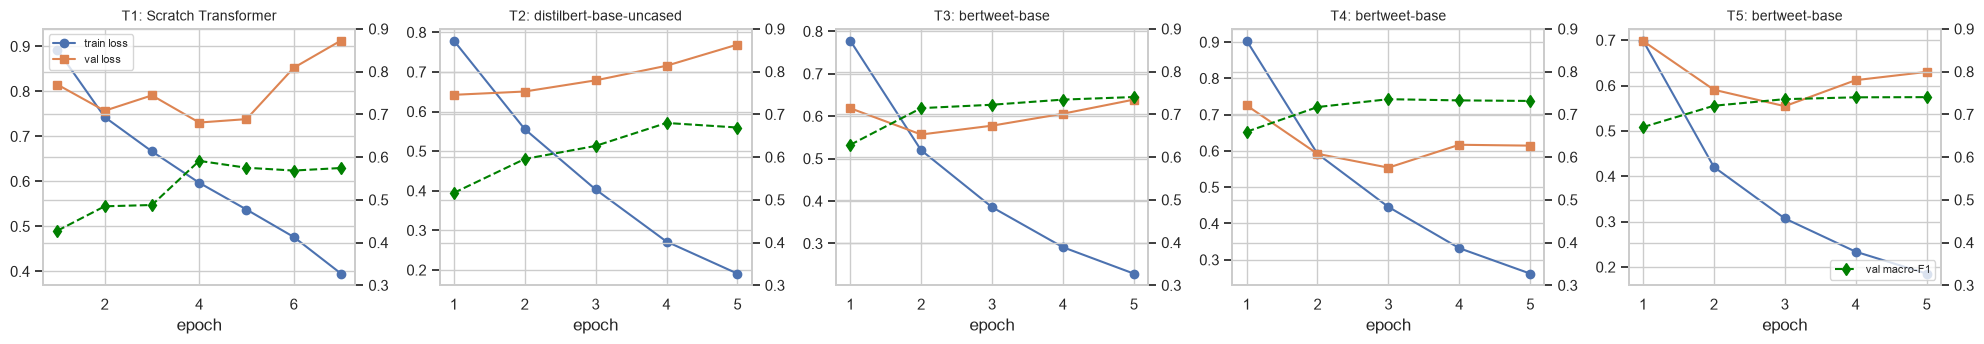

In [18]:
# learning curves
plot_ids = ['T1', 'T2', 'T3', 'T4', 'T5']
fig, axes = plt.subplots(1, len(plot_ids), figsize=(4 * len(plot_ids), 3.6), sharey=False)
for ax, k in zip(axes, plot_ids):
    h = RESULTS[k]['hist']
    ax.plot(h.epoch, h.train_loss, 'o-', label='train loss')
    ax.plot(h.epoch, h.val_loss, 's-', label='val loss')
    ax2 = ax.twinx(); ax2.plot(h.epoch, h.val_macro_f1, 'd--', c='green', label='val macro-F1'); ax2.set_ylim(0.3, 0.9)
    ax.set_title(f"{k}: {RESULTS[k]['row']['model']}", fontsize=10); ax.set_xlabel('epoch')
axes[0].legend(loc='upper left', fontsize=8); ax2.legend(loc='lower right', fontsize=8)
plt.tight_layout(); savefig('learning_curves'); plt.show()

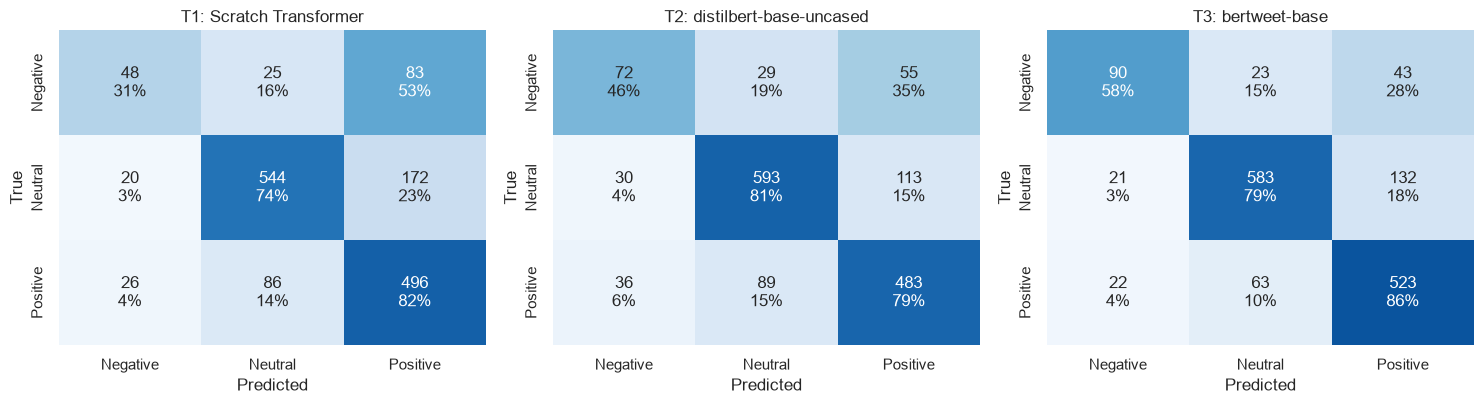

Classification report — T3
              precision    recall  f1-score   support

    Negative      0.677     0.577     0.623       156
     Neutral      0.871     0.792     0.830       736
    Positive      0.749     0.860     0.801       608

    accuracy                          0.797      1500
   macro avg      0.766     0.743     0.751      1500
weighted avg      0.802     0.797     0.797      1500



In [19]:
# confusion matrices
y_test = test_df.label_idx.values
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, k in zip(axes, ['T1', 'T2', FINAL]):
    cm = confusion_matrix(y_test, RESULTS[k]['test_probs'].argmax(1))
    cmn = cm / cm.sum(1, keepdims=True)
    sns.heatmap(cmn, annot=np.array([[f'{v}\n{p:.0%}' for v, p in zip(r1, r2)] for r1, r2 in zip(cm, cmn)]),
                fmt='', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, cbar=False, vmin=0, vmax=1)
    ax.set(title=f"{k}: {RESULTS[k]['row']['model']}", xlabel='Predicted', ylabel='True')
plt.tight_layout(); savefig('confusion_matrices'); plt.show()
print(f'Classification report — {FINAL}')
print(classification_report(y_test, RESULTS[FINAL]['test_probs'].argmax(1), target_names=CLASS_NAMES, digits=3))

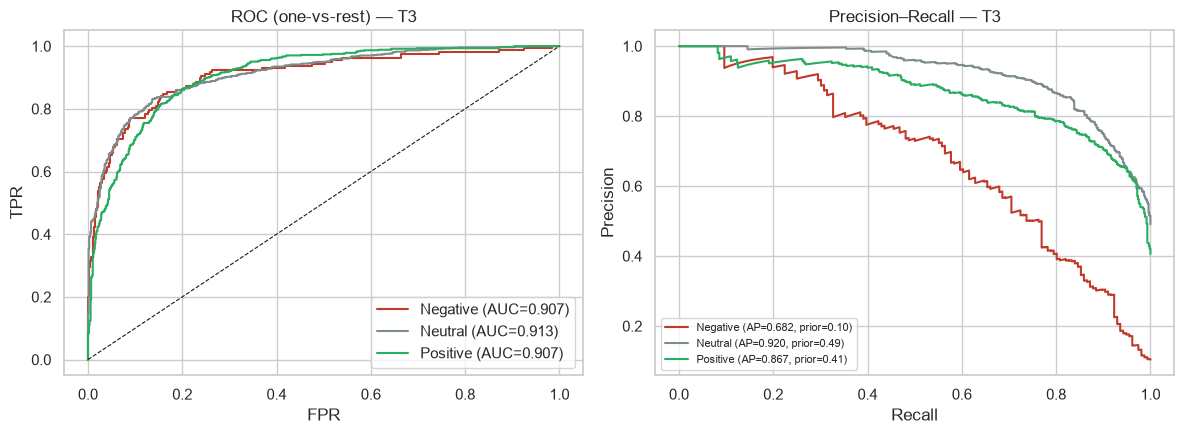

In [20]:
# ROC and precision-recall curves for the final model
probs = RESULTS[FINAL]['test_probs']
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for c, col in zip(range(3), ['#c0392b', '#7f8c8d', '#27ae60']):
    fpr, tpr, _ = roc_curve(y_test == c, probs[:, c])
    ax[0].plot(fpr, tpr, c=col, label=f'{CLASS_NAMES[c]} (AUC={roc_auc_score(y_test == c, probs[:, c]):.3f})')
    pr, rc, _ = precision_recall_curve(y_test == c, probs[:, c])
    ax[1].plot(rc, pr, c=col, label=f'{CLASS_NAMES[c]} (AP={average_precision_score(y_test == c, probs[:, c]):.3f}, prior={np.mean(y_test == c):.2f})')
ax[0].plot([0, 1], [0, 1], 'k--', lw=.8); ax[0].set(title=f'ROC (one-vs-rest) — {FINAL}', xlabel='FPR', ylabel='TPR'); ax[0].legend()
ax[1].set(title=f'Precision–Recall — {FINAL}', xlabel='Recall', ylabel='Precision'); ax[1].legend(fontsize=8)
plt.tight_layout(); savefig('roc_pr_final'); plt.show()

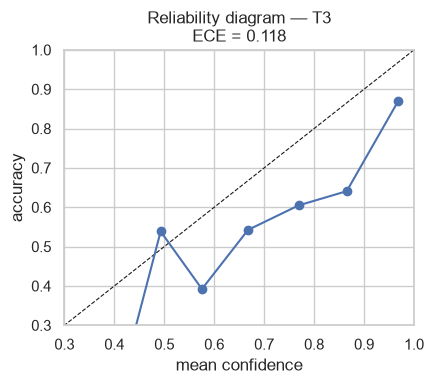

In [21]:
# calibration: does the confidence match the accuracy?
conf, correct = probs.max(1), probs.argmax(1) == y_test
bins = np.linspace(1/3, 1, 8); idx = np.digitize(conf, bins) - 1
cal = pd.DataFrame({'bin': idx, 'conf': conf, 'acc': correct}).groupby('bin').agg(conf=('conf', 'mean'), acc=('acc', 'mean'), n=('acc', 'size'))
ece = (cal.n / cal.n.sum() * (cal.conf - cal.acc).abs()).sum()
plt.figure(figsize=(4.5, 4)); plt.plot([0, 1], [0, 1], 'k--', lw=.8)
plt.plot(cal.conf, cal.acc, 'o-'); plt.xlim(.3, 1); plt.ylim(.3, 1)
plt.title(f'Reliability diagram — {FINAL}\nECE = {ece:.3f}'); plt.xlabel('mean confidence'); plt.ylabel('accuracy')
plt.tight_layout(); savefig('calibration_final'); plt.show()

### Results discussion

| Step | Change | Val macro-F1 | Test macro-F1 | Test Neg. recall |
|---|---|---|---|---|
| T1 | from scratch (4.2M params) | 0.591 | 0.632 | 0.31 |
| T2 | DistilBERT | 0.680 | 0.692 | 0.46 |
| T3 | BERTweet | 0.741 | 0.751 | 0.58 |
| T4 | + class weights | 0.735 | 0.745 | 0.53 |
| T5 | + class and agreement weights | 0.740 | 0.751 | 0.66 |
| T6 | LR 1e-5 / 3e-5 / 5e-5 | 0.720 to 0.731 | 0.739 to 0.751 | |
| T7 | T3 with 3 seeds | 0.731 ± 0.009 | 0.735 ± 0.014 | 0.56 ± 0.02 |

The Transformer trained from scratch scores about the same as the SVM (0.643), CNN (0.646) and LSTM (0.630). Its learning curve shows overfitting from epoch 4. With only 7k tweets, self-attention on its own doesn't have an advantage, since it lacks the built-in assumptions that help CNNs (local patterns) and LSTMs (word order) learn from less data.

Pre-training makes the difference. DistilBERT adds about 0.06 macro-F1 over the scratch model, which matches what Devlin et al. (2019) and Sun et al. (2019) report for BERT-style models.

BERTweet adds another 0.06, and Negative recall goes from 0.46 to 0.58. This fits the EDA: its tokenizer handles hashtags better (3.2 pieces vs 4.1) and it was trained with the same `@USER`/`HTTPURL` tokens. Gururangan et al. (2020) found the same benefit from in-domain pre-training. BERTweet is also twice the size of DistilBERT, so we can't fully separate domain from size here.

Class weights, agreement weights and the LR sweep changed validation macro-F1 by about 0.01 or less, while the seed standard deviation is 0.014. So these changes are within noise. We saw this in a second full run too: there the weighted model with LR 3e-5 was selected (test 0.756, seeds 0.747 ± 0.010), while here plain BERTweet won (test 0.751, seeds 0.735 ± 0.014). The one effect that held up is that class and agreement weights push Negative recall up (0.58 to 0.66) without lowering macro-F1. That could be worth it if missing a hesitant tweet costs more than a false alarm.

The CNN and LSTM in the group notebook use class weights to find more Negative tweets. That gives them Negative recall of 0.53 and 0.62, close to BERTweet's 0.58, but their Negative precision is low (0.43 and 0.32), so many of their Negative predictions are wrong. BERTweet's Negative precision is 0.68, so its Negative F1 is 0.62 compared to 0.47 (CNN) and 0.42 (LSTM). The pre-trained model already separates the classes well (ROC-AUC about 0.91), so for it the weights only shift the decision threshold a little.

Compared with the rest of the group, the final model improves macro-F1 by about 0.11 to 0.12 (0.751 vs 0.643 for SVM, 0.646 for CNN and 0.630 for LSTM). The cost is about 9 minutes of GPU training per run and a much bigger model than the SVM.

## 7. Error analysis

Looking at where the final model goes wrong:
1. error rate by annotator agreement
2. error rate by length, negation and hashtags
3. the most confident mistakes
4. word importance (occlusion) for a few examples

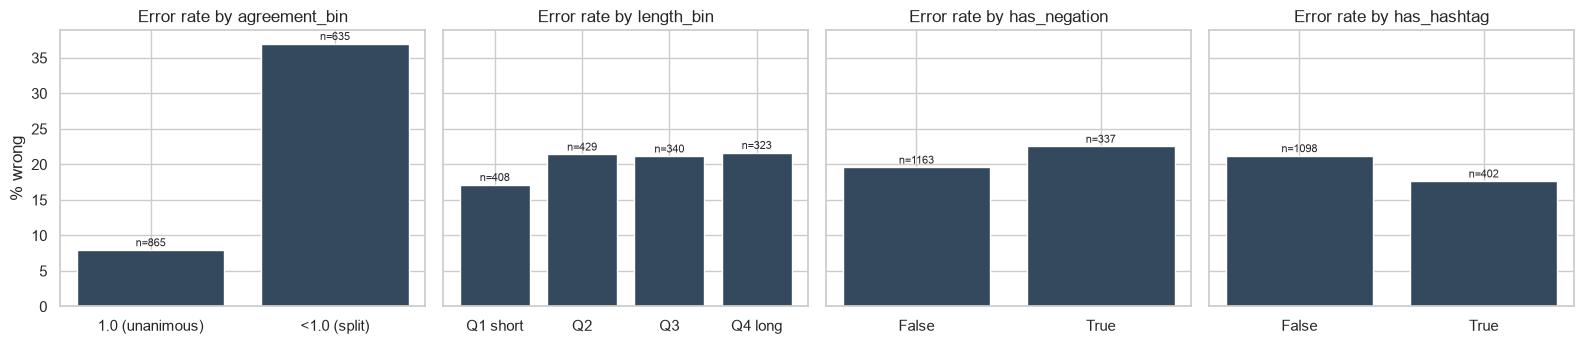

1.0 (unanimous)  n= 865  macro-F1=0.872  acc=0.920
<1.0 (split)     n= 635  macro-F1=0.604  acc=0.630


In [22]:
err = test_df.copy()
err['pred'] = probs.argmax(1); err['conf'] = probs.max(1); err['wrong'] = err.pred != err.label_idx
err['n_tok'] = [len(RESULTS[FINAL]['tok'].encode(s)) for s in err.text]
err['agreement_bin'] = err.agreement.fillna(1).map(lambda a: '1.0 (unanimous)' if a >= 1 else '<1.0 (split)')
err['length_bin'] = pd.qcut(err.n_tok, 4, labels=['Q1 short', 'Q2', 'Q3', 'Q4 long'])
err['has_hashtag'] = err.text.str.contains('#')
err['has_negation'] = err.text.str.lower().str.contains(NEG_WORDS)
err['has_url'] = err.text.str.contains('HTTPURL')

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for ax, col in zip(axes, ['agreement_bin', 'length_bin', 'has_negation', 'has_hashtag']):
    g = err.groupby(col, observed=True).wrong.agg(['mean', 'size'])
    ax.bar(g.index.astype(str), g['mean'] * 100, color='#34495e')
    for i, (m, n) in enumerate(zip(g['mean'], g['size'])): ax.text(i, m * 100 + .5, f'n={n}', ha='center', fontsize=8)
    ax.set(title=f'Error rate by {col}', ylabel='% wrong' if col == 'agreement_bin' else '')
plt.tight_layout(); savefig('error_rate_by_slice'); plt.show()

# macro-F1 on unanimous vs split tweets
for b, g in err.groupby('agreement_bin'):
    print(f'{b:16s} n={len(g):4d}  macro-F1={f1_score(g.label_idx, g.pred, average="macro"):.3f}  acc={1-g.wrong.mean():.3f}')

In [23]:
# most common confusions and the most confident mistakes
pd.set_option('display.max_colwidth', 160)
lab = dict(enumerate(CLASS_NAMES))
pairs = err[err.wrong].groupby(['label_idx', 'pred']).size().rename('count').reset_index()
pairs['confusion'] = pairs.label_idx.map(lab) + ' → ' + pairs.pred.map(lab)
display(pairs.sort_values('count', ascending=False)[['confusion', 'count']].set_index('confusion').T)

worst = err[err.wrong].sort_values('conf', ascending=False).head(15)
display(worst.assign(true=worst.label_idx.map(lab), predicted=worst.pred.map(lab))[['safe_text', 'true', 'predicted', 'conf', 'agreement']].round(2))
worst.to_csv(f'{OUT_DIR}/most_confident_errors.csv', index=False)

confusion,Neutral → Positive,Positive → Neutral,Negative → Positive,Negative → Neutral,Positive → Negative,Neutral → Negative
count,132,63,43,23,22,21


,safe_text,true,predicted,conf,agreement
6,<user> no immunity? No schools other than hone-school.,Positive,Neutral,0.99,0.67
831,"After the news of a #BART passenger possibly spreading Measles, riding public transit feels like an episode of The Walking Dead.",Positive,Neutral,0.98,0.67
622,Large measles outbreak traced to Disneyland is declared over: California health authorities on Friday declared an… <url>,Negative,Neutral,0.98,0.33
976,FDA Commissioner says measles outbreak 'alarming' <url> #WASHINGTON #UnitedStates <url>,Negative,Neutral,0.98,0.33
455,<user> <user> Grocery store Hou. TX. 5 yr. old alien dotted with measles-he or mom doesn't understand me/nobody cares!,Positive,Neutral,0.98,0.67
1117,"SB30 [Update] In child protective services, further providing for definitions, for immunity from liability, for e... <url>",Negative,Neutral,0.98,0.33
32,"Warning about possible measles exposure in Seattle, Kirkland, Mercer Island: SEATTLE — Public health officials on... <url>",Positive,Neutral,0.98,0.67
269,“<user> what's life without the risks.”👌💯,Negative,Neutral,0.98,0.67
1480,Who wants a shot of autism juice...I mean measles vaccine!? #ThingsMyDoctorSays <user>,Negative,Neutral,0.98,1.00
261,<user> #GOP STOP blaming #Immigrants first #Ebola now #measles Which diseases?brought their ancestors? #AINF <url>,Positive,Neutral,0.98,0.67


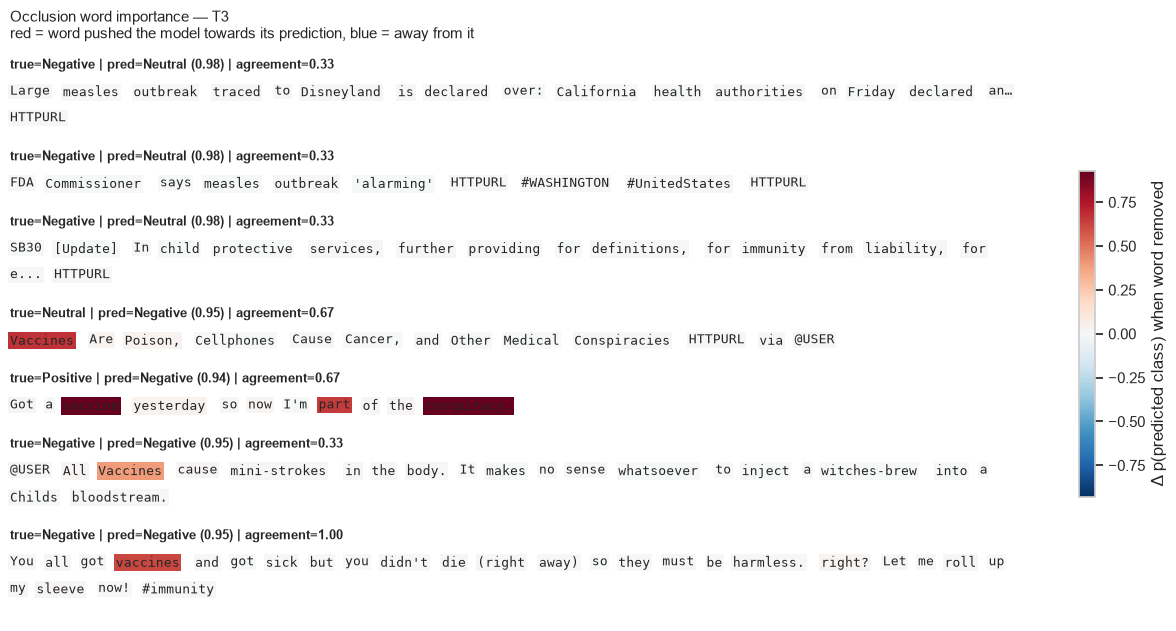

In [24]:
# occlusion: remove one word at a time and see how the predicted probability changes
assert BEST['exp'] == FINAL, (BEST['exp'], FINAL)
final_model, final_tok = BEST['model'].to(DEVICE), RESULTS[FINAL]['tok']

@torch.no_grad()
def class_probs(texts):
    enc = final_tok(texts, truncation=True, max_length=MAX_LEN, padding=True, return_tensors='pt').to(DEVICE)
    final_model.eval()
    return logits_of(final_model, enc['input_ids'], enc['attention_mask']).float().softmax(-1).cpu().numpy()

def occlusion(text, target):
    words = text.split()
    variants = [' '.join(words[:i] + words[i + 1:]) for i in range(len(words))]
    base = class_probs([text])[0, target]
    return words, base - class_probs(variants)[:, target]

def show_occlusion(rows, title, width=115):
    data = [(r, *occlusion(r.text, int(r.pred))) for _, r in rows.iterrows()]
    vmax = max(max(abs(imp).max() for _, _, imp in data), 1e-3)
    cmap, norm = plt.cm.RdBu_r, plt.Normalize(-vmax, vmax)
    n_lines = sum(2.6 + sum(len(w) + 1 for w in words) // width for _, words, _ in data)
    fig, ax = plt.subplots(figsize=(14, 0.3 * n_lines + 0.8)); ax.axis('off')
    y = 0
    for r, words, imp in data:
        ax.text(0, y, f'true={lab[r.label_idx]} | pred={lab[r.pred]} ({r.conf:.2f}) | agreement={r.agreement:.2f}',
                fontsize=9, weight='bold', va='top'); y += 1.1
        x = 0
        for w, v in zip(words, imp):
            if x + len(w) > width: x, y = 0, y + 1.1
            ax.text(x, y, w, family='monospace', fontsize=9, va='top', color='white' if abs(norm(v) - .5) > .3 else 'black',
                    bbox=dict(facecolor=cmap(norm(v)), edgecolor='none', pad=1.2))
            x += len(w) + 1
        y += 1.6
    ax.set_xlim(0, width + 5); ax.set_ylim(y, -0.5)
    fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.015, pad=0.01,
                 label='Δ p(predicted class) when word removed')
    ax.set_title(title + '\nred = pushed towards the prediction, blue = pushed away', loc='left', fontsize=11)
    return fig

rows = pd.concat([err[err.wrong & (err.label_idx == 0)].nlargest(3, 'conf'),
                  err[err.wrong & (err.pred == 0)].nlargest(2, 'conf'),
                  err[~err.wrong & (err.label_idx == 0) & err.has_negation].nlargest(2, 'conf')])
show_occlusion(rows, f'Occlusion word importance — {FINAL}'); savefig('occlusion_examples'); plt.show()

### Error analysis findings

- Most mistakes are on tweets where annotators disagreed. The error rate is 8.0% when all annotators agreed and 37.0% when they didn't (macro-F1 0.872 vs 0.604). Those tweets are 42% of the test set but 77% of the errors. Some of these "errors" are really unclear labels.
- Negative tweets are hard partly because their labels are noisy (only 41% of Negative test tweets are unanimous). Several confident Negative→Neutral mistakes are news headlines with agreement 0.33, for example "Large measles outbreak traced to Disneyland is declared over". The model's Neutral prediction is reasonable there.
- The most common mistake is Neutral→Positive (132 tweets). A lot of neutral tweets are health news that uses the same words as pro-vaccine tweets.
- Sarcasm is still a problem. "Got a vaccine yesterday so now I'm part of the conspiracy" is labelled Positive (it mocks anti-vaxxers) but predicted Negative, and the occlusion map shows "vaccine" and "conspiracy" pushed it there. The sarcastic tweet "...so they must be harmless. right? Let me roll up my sleeve now!" was classified correctly, so it doesn't fail on every sarcastic tweet.
- Some gold labels look wrong. "Vaccines Are Poison, Cellphones Cause Cancer, and Other Medical Conspiracies" is the title of an article about conspiracies (labelled Neutral, predicted Negative). One tweet also appears twice in the test set (rows 261 and 532).
- Negation and hashtags have a small effect next to agreement: 22.6% errors with negation vs 19.6% without, 17.6% with hashtags vs 21.2% without.
- The model is overconfident (ECE about 0.12). When it is 85–95% confident it is right only about 64% of the time, so the scores would need calibration, e.g. temperature scaling (Guo et al., 2017), before being used as probabilities.

## 8. Export results

In [25]:
# save test predictions for the group comparison
pd.DataFrame({'tweet_id': test_df.tweet_id, 'label_idx': y_test,
              **{f'p_{c}': probs[:, i] for i, c in enumerate(CLASS_NAMES)}}).to_csv(f'{OUT_DIR}/final_test_predictions.csv', index=False)
print('Saved to', OUT_DIR, ':', sorted(os.listdir(OUT_DIR)))

Saved to results/transformer : ['figures', 'final_test_predictions.csv', 'most_confident_errors.csv', 'transformer_experiments.csv']


## 9. Conclusion and limitations

BERTweet fine-tuned on our training set was the best of the five approaches in the group: test macro-F1 0.751 (0.735 ± 0.014 over 3 seeds), accuracy 0.80, ROC-AUC 0.91, Negative recall 0.58 to 0.66. The experiments show that self-attention alone doesn't beat the CNN, LSTM or SVM. The gain comes from pre-training (about +0.06), and pre-training on tweets adds about the same again. Class and agreement weights mainly change the balance between Negative precision and recall.

Limitations:
- Label noise: 42% of test tweets don't have full agreement and they account for 77% of errors, so part of what we measure is annotator disagreement.
- One split and 3 seeds. With 156 Negative test tweets, one tweet is about 0.6 points of Negative recall, so differences under about 0.02 macro-F1 shouldn't be read too much into.
- BERTweet differs from DistilBERT in both domain and size. A model like RoBERTa-base would separate the two.
- The model is overconfident (ECE about 0.12).
- Only the learning rate was tuned.

Future work: temperature scaling, training on soft labels from annotator votes, trying COVID-Twitter-BERT (Müller et al., 2023), adding a RoBERTa-base comparison, and combining the Transformer with the SVM.

Responsible AI:
- A model like this could help health teams track vaccine hesitancy over time. It could also be misused to target people who post hesitant views, so it should only be used for overall trends, not on individuals.
- The data are English tweets from the measles/Ebola period. The model hasn't been tested on African languages, code-switched text or newer topics like COVID-19 vaccines, and it would need new labelled data before being used there. Pre-trained models also carry biases from their training text.
- Mistaking sarcasm or news for hesitancy could make anti-vaccine sentiment look bigger than it is, so people should check the outputs.
- The tweets are already anonymised (`<user>`, `<url>`) and we kept them that way.

## References

* Barbieri, F., Camacho-Collados, J., Espinosa Anke, L., & Neves, L. (2020). TweetEval: Unified benchmark and comparative evaluation for tweet classification. *Findings of EMNLP 2020*.
* Chicco, D., & Jurman, G. (2020). The advantages of the Matthews correlation coefficient (MCC) over F1 score and accuracy in binary classification evaluation. *BMC Genomics, 21*(6).
* Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. *NAACL-HLT 2019*.
* Dodge, J., Ilharco, G., Schwartz, R., Farhadi, A., Hajishirzi, H., & Smith, N. (2020). Fine-tuning pretrained language models: Weight initializations, data orders, and early stopping. *arXiv:2002.06305*.
* Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). On calibration of modern neural networks. *ICML 2017*.
* Gururangan, S., Marasović, A., Swayamdipta, S., Lo, K., Beltagy, I., Downey, D., & Smith, N. A. (2020). Don't stop pretraining: Adapt language models to domains and tasks. *ACL 2020*.
* Johnson, J. M., & Khoshgoftaar, T. M. (2019). Survey on deep learning with class imbalance. *Journal of Big Data, 6*(27).
* Loshchilov, I., & Hutter, F. (2019). Decoupled weight decay regularization. *ICLR 2019*.
* Monroe, B. L., Colaresi, M. P., & Quinn, K. M. (2008). Fightin' words: Lexical feature selection and evaluation for identifying the content of political conflict. *Political Analysis, 16*(4).
* Mosbach, M., Andriushchenko, M., & Klakow, D. (2021). On the stability of fine-tuning BERT: Misconceptions, explanations, and strong baselines. *ICLR 2021*.
* Müller, M., Salathé, M., & Kummervold, P. E. (2023). COVID-Twitter-BERT: A natural language processing model to analyse COVID-19 content on Twitter. *Frontiers in Artificial Intelligence, 6*, 1023281.
* Müller, M., & Salathé, M. (2019). Crowdbreaks: Tracking health trends using public social media data and crowdsourcing. *Frontiers in Public Health, 7*, 81.
* Nguyen, D. Q., Vu, T., & Nguyen, A. T. (2020). BERTweet: A pre-trained language model for English Tweets. *EMNLP 2020: System Demonstrations*.
* Rosenthal, S., Farra, N., & Nakov, P. (2017). SemEval-2017 Task 4: Sentiment analysis in Twitter. *SemEval-2017*.
* Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLoS ONE, 10*(3).
* Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter. *arXiv:1910.01108*.
* Sun, C., Qiu, X., Xu, Y., & Huang, X. (2019). How to fine-tune BERT for text classification? *CCL 2019*.
* Vaswani, A., et al. (2017). Attention is all you need. *NeurIPS 2017*.
* Wolf, T., et al. (2020). Transformers: State-of-the-art natural language processing. *EMNLP 2020: System Demonstrations*.
* Zindi (2020). *To Vaccinate or Not to Vaccinate: It's not a Question* [Dataset and challenge]. https://zindi.africa/
* Libraries: PyTorch (Paszke et al., 2019), scikit-learn (Pedregosa et al., 2011), pandas, matplotlib, seaborn.